In [25]:
import numpy as np
import networkx as nx
from grakel import GraphKernel
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.utils import to_networkx

In [26]:
import networkx as nx
from torch_geometric.datasets import TUDataset

# Specify the name of the dataset you want to load
dataset_name = 'ENZYMES'  # Example dataset name

# Load the dataset
dataset = TUDataset(root='data/TUDataset', name=dataset_name)

# Get the first graph from the dataset
data = dataset[0]

# Convert PyG data to NetworkX graph
G1 = nx.Graph()
G1.add_edges_from(data.edge_index.T.numpy())


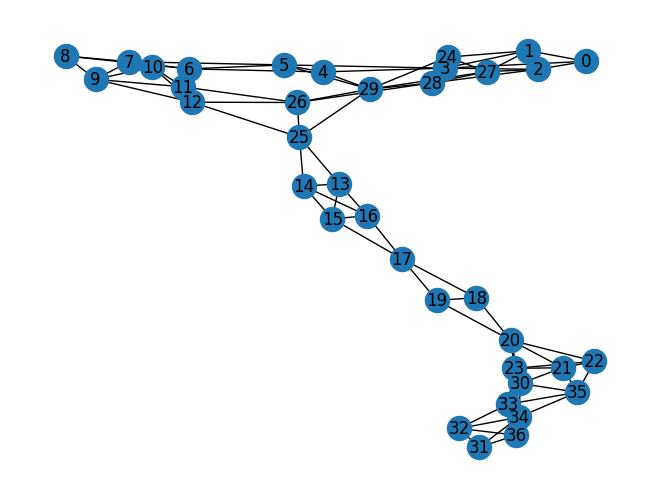

In [27]:
nx.draw(G1, with_labels = True)
plt.show()

In [28]:
# Get the first graph from the dataset
data2 = dataset[1]

# Convert PyG data to NetworkX graph
G2 = nx.Graph()
G2.add_edges_from(data2.edge_index.T.numpy())

# Compute edge weights (e.g., using edge betweenness centrality)
edge_weights2 = nx.edge_betweenness_centrality(G2)

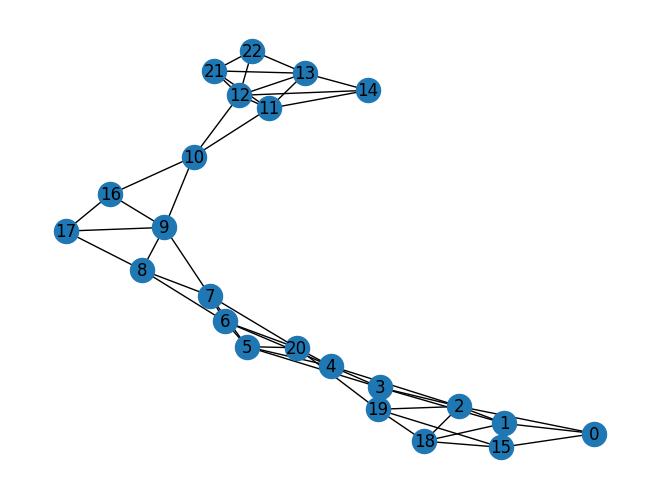

In [29]:
nx.draw(G2, with_labels = True)
plt.show()

In [30]:
# Get the first graph from the dataset
data3 = dataset[2]

# Convert PyG data to NetworkX graph
G3 = nx.Graph()
G3.add_edges_from(data3.edge_index.T.numpy())

# Compute edge weights (e.g., using edge betweenness centrality)
edge_weights2 = nx.edge_betweenness_centrality(G3)

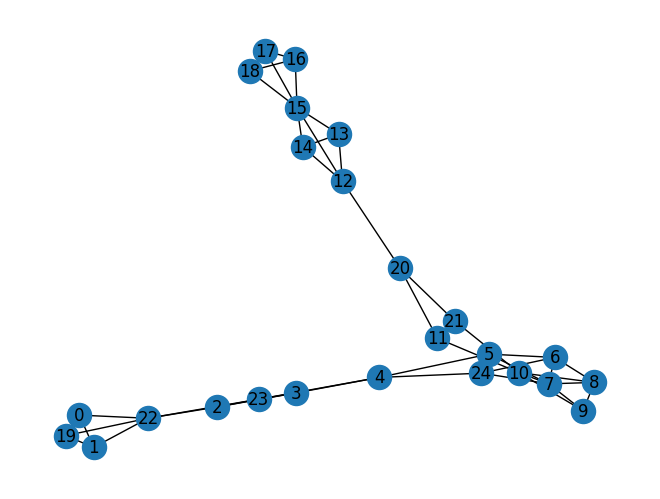

In [31]:
nx.draw(G3, with_labels = True)
plt.show()

In [33]:
import numpy as np
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

def compute_random_walks(graph, num_steps=10, num_walks=10):
    """
    Computes random walks on a graph.

    Parameters:
    graph (NetworkX graph): Input graph.
    num_steps (int): Number of steps for each random walk.
    num_walks (int): Number of random walks to perform for each node.

    Returns:
    walks (list): List of random walks.
    """
    walks = []

    for _ in range(num_walks):
        for node in graph.nodes():
            walk = [node]
            current_node = node

            for _ in range(num_steps - 1):
                neighbors = list(graph.neighbors(current_node))
                if neighbors:
                    next_node = np.random.choice(neighbors)
                    walk.append(next_node)
                    current_node = next_node
                else:
                    break

            walks.append(walk)

    return walks

def compute_similarity(graph1, graph2, num_steps=10, num_walks=10):
    """
    Computes the similarity between two graphs based on random walks.

    Parameters:
    graph1, graph2 (NetworkX graphs): Graphs to compute similarity for.
    num_steps (int): Number of steps for each random walk.
    num_walks (int): Number of random walks to perform for each node.

    Returns:
    similarity (float): Similarity between the two graphs.
    """
    walks_graph1 = compute_random_walks(graph1, num_steps, num_walks)
    walks_graph2 = compute_random_walks(graph2, num_steps, num_walks)

    # Compute the cosine similarity between average walk embeddings
    similarity = cosine_similarity(np.mean(walks_graph1, axis=0).reshape(1, -1), np.mean(walks_graph2, axis=0).reshape(1, -1))[0, 0]

    return similarity

def compute_kernel_matrix(graphs, num_steps=10, num_walks=10):
    """
    Computes the random walk graph kernel matrix for a dataset of graphs.

    Parameters:
    graphs (list): List of NetworkX graphs.
    num_steps (int): Number of steps for each random walk.
    num_walks (int): Number of random walks to perform for each node.

    Returns:
    kernel_matrix (ndarray): Random walk graph kernel matrix.
    """
    num_graphs = len(graphs)
    kernel_matrix = np.zeros((num_graphs, num_graphs))

    for i, graph1 in enumerate(graphs):
        for j, graph2 in enumerate(graphs):
            similarity = compute_similarity(graph1, graph2, num_steps, num_walks)
            kernel_matrix[i, j] = similarity

    return kernel_matrix

In [34]:
graph1 = G1
graph2 = G2

# Convert the graphs to a list
dataset = [graph1, graph2]

# Now you can use the dataset with the functions
# Compute the random walk graph kernel matrix for the dataset
kernel_matrix = compute_kernel_matrix(dataset, num_steps=10, num_walks=10)

print("Random walk graph kernel matrix:")
print(kernel_matrix)

Random walk graph kernel matrix:
[[0.99985481 0.99869884]
 [0.99948798 0.99946619]]


In [35]:
graph1 = G2
graph2 = G3

# Convert the graphs to a list
dataset = [graph1, graph2]

# Now you can use the dataset with the functions
# Compute the random walk graph kernel matrix for the dataset
kernel_matrix = compute_kernel_matrix(dataset, num_steps=10, num_walks=10)

print("Random walk graph kernel matrix:")
print(kernel_matrix)

Random walk graph kernel matrix:
[[0.99853254 0.9982984 ]
 [0.99826851 0.99903693]]


In [36]:
graph1 = G1
graph2 = G3

# Convert the graphs to a list
dataset = [graph1, graph2]

# Now you can use the dataset with the functions
# Compute the random walk graph kernel matrix for the dataset
kernel_matrix = compute_kernel_matrix(dataset, num_steps=10, num_walks=10)

print("Random walk graph kernel matrix:")
print(kernel_matrix)

Random walk graph kernel matrix:
[[0.99988336 0.99919001]
 [0.99947174 0.99902328]]
